# ALGORITMO GENÉTICO
>  É uma variante da busca em feixe estocástica, onde agora os estados sucessores são geradas pela combinação de dois estados (pais) em vez de um único. Aqui temos a "reprodução" sexuada de estados onde dois estados (pais) geram um filho;

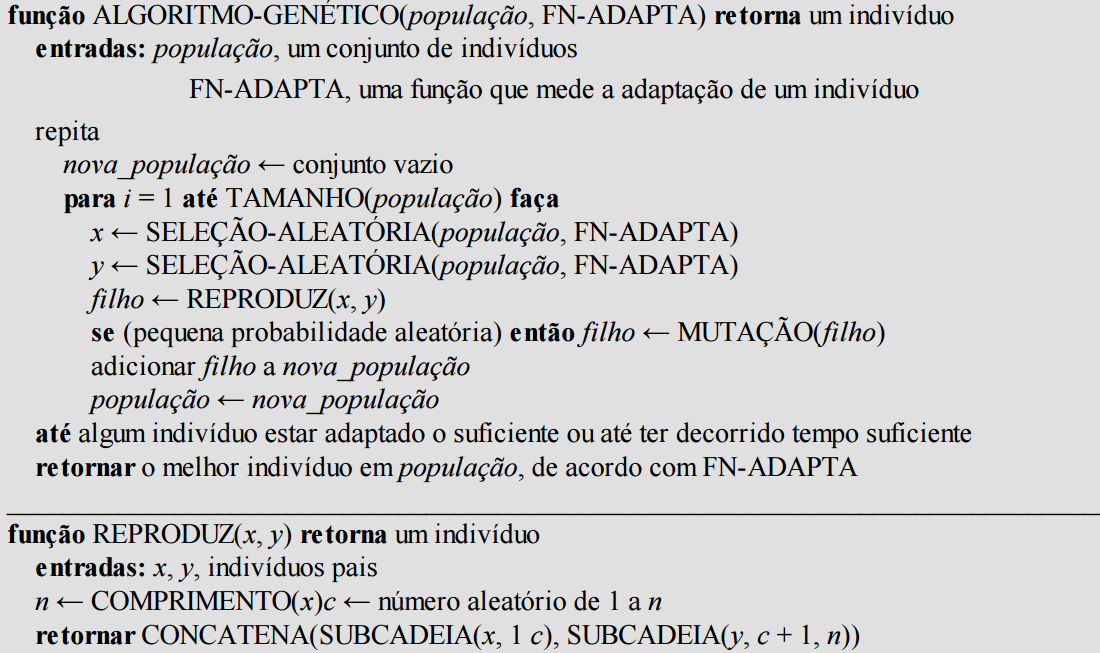

In [2]:
import random

def reproduz(x, y):
    n = len(x)
    c = random.randint(1, n - 1)  # ponto de corte
    filho = x[:c] + y[c:]
    return filho

def mutacao(individuo, prob=0.01):
    novo = individuo[:]
    for i in range(len(novo)):
        if random.random() < prob:
            novo[i] = 1 - novo[i]  # inverte bit
    return novo

def selecao_aleatoria(populacao, fitness_fn):
    total_fitness = sum(fitness_fn(ind) for ind in populacao)
    r = random.uniform(0, total_fitness)
    acumulado = 0
    for ind in populacao:
        acumulado += fitness_fn(ind)
        if acumulado >= r:
            return ind
        

def fitness(individuo):
    return sum(individuo)  # quantidade de 1s


def algoritmo_genetico(populacao, fitness_fn, geracoes=100):
    for _ in range(geracoes):
        nova_populacao = []
        
        for _ in range(len(populacao)):
            x = selecao_aleatoria(populacao, fitness_fn)
            y = selecao_aleatoria(populacao, fitness_fn)
            
            filho = reproduz(x, y)
            filho = mutacao(filho, prob=0.01)
            
            nova_populacao.append(filho)
        
        populacao = nova_populacao
    
    return max(populacao, key=fitness_fn)

def cria_populacao(tamanho_pop, tamanho_ind):
    return [
        [random.randint(0, 1) for _ in range(tamanho_ind)]
        for _ in range(tamanho_pop)
    ]

pop = cria_populacao(20, 10)
melhor = algoritmo_genetico(pop, fitness)

print("Melhor indivíduo:", melhor)
print("Fitness:", fitness(melhor))

Melhor indivíduo: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Fitness: 10
